- RNN의 한계
    - Attention의 등장 배경 및 장점
    - Attention is All You Need
- Self-Attention
    - Query, Key, Value 개념
    - Cross Attention vs. Self-Attention 개념 및 과정
    - Scaled Dot-Product Attention
- Multi-Head Attention
    - Multi-Head Attention 개념
    - Multi-Head Attention 작동 방식
- Transformer 전체 아키텍처
    - 전처리 단계(토큰화 - 임베딩 - Positional Encoding)
    - Encoder와 Decoder

# RNN의 한계
## Attention의 등장배경
> **Seq2Seq의 병목 현상**
- 기존 Seq2Seq 모델은 입력 문장의 모든 정보를 하나의 **고정된 Context Vector**에 압축
- Decoder는 이 Context Vector만을 이용해 출력 문장을 생성
- But, 입력 문장이 길어질수록 하나의 벡터에 모든 정보를 담기 어려워지고, 중요한 정보가 손실되는 문제 발생
- Decoder는 매번 같은 Context Vector만 참고하기 때문에, 출력 단어마다 필요한 정보를 다르게 반영하기 어려움
- 이를 해결하기 위해 Attention이 등장
- Attention은 Decoder가 단어를 생성할 때마다 입력 문장 전체를 다시 보고, 현재 단어와 관련 있는 부분에 더 집중하여 새로운 Context Vector를 만듦

> ### ATTENTION

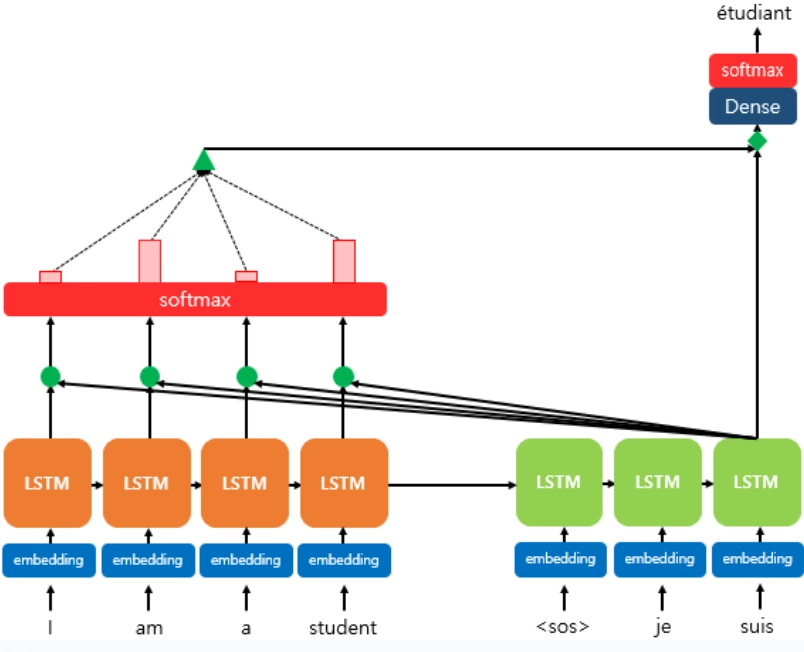
- Attention은 말 그대로 중요한 정보에 더 집중하는 메커니즘
- 결과를 만들 때 입력값의 모든 부분을 똑같이 참고하는 것이 아니라, **현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여하여 활용**
- 즉, 출력 단어를 생성할 때 입력 문장 속 단어들 중 어떤 단어에 얼마나 집중할지 결정하는 기술
- **Seq2Seq 방식과 비교했을 때, 가장 중요한 차이점**
    - **출력 시점마다 새로운 context vector를 동적으로 계산**한다는 점
    - 즉, **병렬화**

### Attention 메커니즘의 장점
> ① 시간 경과에 대한 유연성 (vs RNN)

- RNN은 고질적인 한계인, **장기 의존성 문제**가 있음
- Attention은 **모든 단어에서 다른 모든 단어로 직접 연결** 가능
- 따라서 아무리 멀리 떨어진 단어 사이의 관계라도 정보 손실 없이 명확하게 파악 가능
- → 시간적(순서적) 거리에 제약을 받지 않는 유연성 확보

> ② 공간에 대한 유연성 (vs CNN)

- CNN은 **'고정된 필터(Filter)'**를 사용해 이미지의 지역적인(local) 부분을 중심으로 정보 처리
- Attention은 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결되어, 픽셀 간의 거리에 상관없이 한 번에 전체 이미지의 **전역적인 관계**를 학습 가능
→ 이미지 내 복잡한 상호작용을 훨씬 유연하게 포착 가능

> ③ **병렬화 (vs RNN)**

- RNN은 구조적으로 **순차 계산**이 필수적이기 때문에 병렬 처리가 어렵고 학습 속도가 매우 느리다는 단점 존재
- Attention은 **self-attention**에서 문장 내 **모든 단어의 관계를 한번에, 독립적으로 계산**할 수 있음
- 따라서 병렬 처리가 가능하고, 긴 시퀀스도 더 효율적으로 학습 가능

⇒ 어텐션 메커니즘은 NLP 분야의 LLM뿐만 아니라, 이미지 생성에 사용되는 확산 모델이나 비전 분야에서 물체 감지, 이미지 분할과 같은 다양한 작업에서 우수한 성능 발휘

## Attention is All You Need
- Google Brain의 논문
- Transformer 구조를 처음 발표 (Self-Attention 방식)

**⇒ 반향: Attention을 쓰던 딥러닝 모델들이 대부분 Self-Attention 방식을 채택하게 됨.**
- GPT, Gemini, Claude, DeepSeek, LLaMa, EXAONE 등

### 본 논문 내용
> ① 논문 배경 : RNN과 RNN 기반 모델들의 한계점 (느린 학습 속도, 장기 의존성 문제)

**→** 순차적 계산 구조를 아예 제거하고,인코더부터 디코더까지 **오직 Attention만을 사용하는 모델**을 만들면 어떨까?

> ② Transformer의 등장 

: 위 배경에 따라, Attention is All You Need 에서는 RNN의 순환 구조를 완전히 제거하고, **self-attention에 기반한 Transformer 모델을 제안**

> ③ 논문에서 가장 중요한 **발견**

- 성공적인 모델링에 **Recurrence 및 Convolution이 필수가 아님**을 증명하여 기존 RNN 기반 모델들이 사용하던 순환 구조 없이도 Attention만으로 더 좋은 성능을 낼 수 있음을 보여줌
- 또한 모든 단어들을 동시에 계산할 수 있는 **병렬화** 가능

→ 위 결과로, 모델 학습 속도를 획기적으로 단축시켰을 뿐만 아니라, 훨씬 더 거대한 데이터를 다룰 수 있는 모델들을 제작 가능하게 됨

> ④ 파급효과
- **LLM의 탄생**: 트랜스포머는 **BERT**와 **GPT**라는 두 거대 모델의 직접적인 기반이 됨
- **NLP 평정**: 번역, 요약, 챗봇 등 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리잡게 됨
- **타 분야로의 확장**: 트랜스포머의 성공은 AI를 NLP를 넘어 **컴퓨터 비전(Vision Transformer), 음성 처리, 신약 개발** 등 모든 영역으로 확장시킴

# Self-Attention
## Query, Key, Value
**쿼리(Query), 키(Key), 밸류(Value)**

→ 모델이 수많은 정보 안에서 **가장 관련 있는 정보를 효과적으로 찾아내기(Attention)** 위해 3가지 역할로 분할한 것

> **Q : Query**

- 말 그대로 **'질문'** 또는 **'요청'**으로, 지금 당장 내가 알고 싶거나, 초점을 맞추고 있는 대상

> **K : Key**

- 검색 대상이 되는 **모든 정보들이 달고 있는 '이름표' 또는 '색인'** 
- 쿼리는 이 키들과 자신을 비교하며 얼마나 관련이 있는지 확인힙니다!

> **V : Value**
- 키와 한 쌍으로 묶여 있는 **'실제 내용물'**
- 쿼리와 키의 관련도 계산이 끝나고, 가장 관련성이 높다고 판단된 키가 선택되면, 모델은 그 키에 해당하는 밸류를 가져와 사용


## 기존 Cross-Attention vs. Self-Attention
### 기존 Attention in Seq2Seq (Cross-Attention)

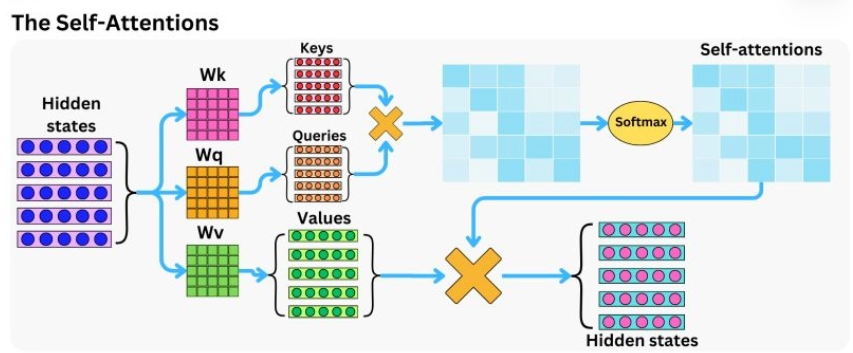
- 번역할 문장을 슬쩍슬쩍 보면서 단어를 생성
    - Query와  Key - Value쌍이 서로 다른 시퀀스에서 출력
- Cross - Attention은 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘
- -> Decoder가 Encoder를 참고하는 과정

### Self-Attention

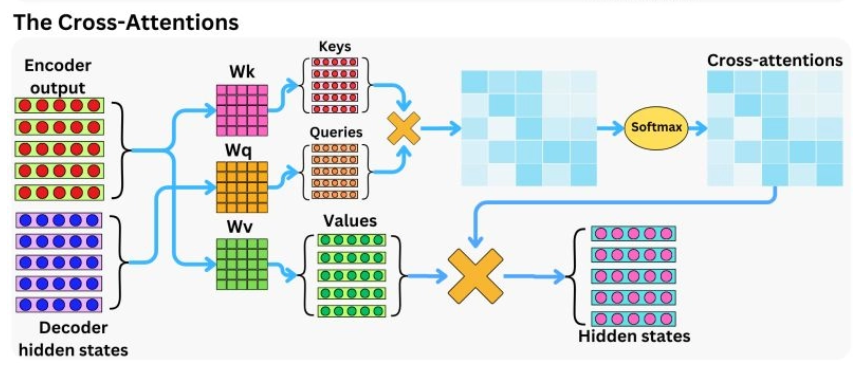
- 문장 자체를 뜯어보며 내부의 관계를 파악
    - Query와  Key - Value쌍이 같은 시퀀스에서 출력
    - 문장 스스로가 문맥을 이해하는 과정

### Scaled Dot-Product Attention
####  Dot-Product Attention
- Dot-Product Attention은 Attention Score를 계산하는 가장 기본적인 방법 중 하나
- 쿼리(Query)와 키(Key) 벡터를 내적(Dot Product)하여 유사도를 구함

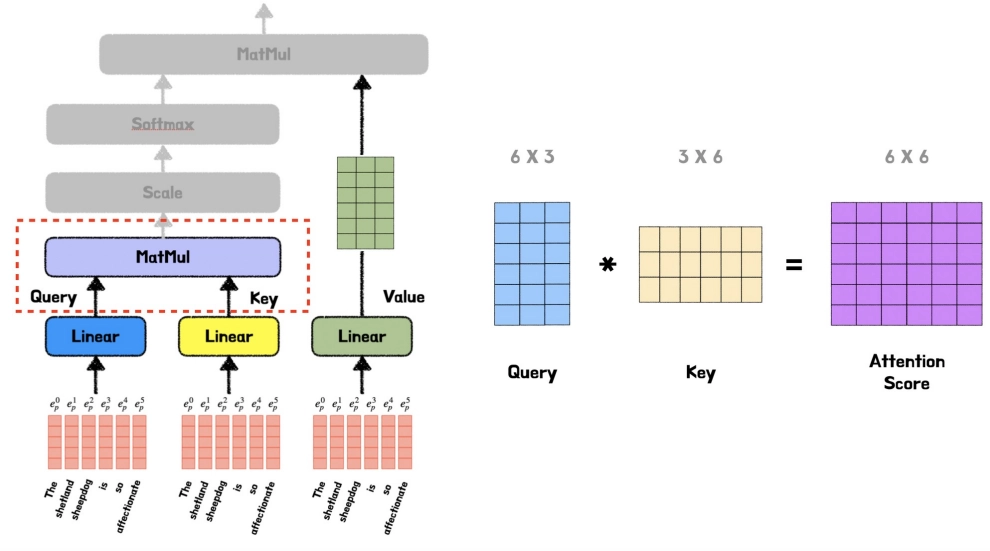

문제점  : Attention Score의 극단화 

- 벡터 차원 $d_k$가 커질수록 내적값이 지나치게 커지거나 작아질 수 있음
- 이런 극단적인 값이 Softmax에 입력되면 특정 단어에 확률이 과도하게 집중되고, gradient가 0에 가까워지는 **Vanishing Gradient 문제**가 발생할 수 있음

# Multi-Head Attention
- 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습
- Attention is all you need 에서는 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러 번 계산 하는데, 이 과정이 **Multi-Head Attention**

## Multi-Head Attention 작동 방식
- “I love you”라는 문장에서 “love”라는 단어의 벡터가 Multi-Head Attention layer를 통과하는 과정을 예시로 설명
- 각 단어의 차원, 어텐션 헤드의 수, 각 헤드의 차원은 *Attention is all you need* 논문과 같이 각각 512차원, 8개, 64차원으로 가정
--- 
1. 분할 (Projection) - 8명의 헤드에 단어 벡터 할당
    - 가장 먼저, 'love'라는 단어를 나타내는 하나의 512차원 벡터가 들어옴
    - 멀티-헤드 어텐션은 이 큰 벡터를 통째로 처리하지 않고, 이 벡터를 8개의 작은 벡터 그룹(Q, K, V)으로 투영(projection) 하여 8개의 서로 다른 관점으로 나눔
    > **입력**: `love_vector` (크기: 1×512)
    
    - 이 입력 벡터에 8세트의 서로 다른 가중치 행렬을 곱함
    
    - `Query_1` = `love_vector` × $W_1^Q$ (결과 크기: 1×64)
    - `Key_1` = `love_vector` ×$W_1^K$(결과 크기: 1×64)
    - `Value_1` = `love_vector` × $W_1^V$(결과 크기: 1×64)
        
        …
        
    - `Query_8` = `love_vector` ×$W_8^Q$ (결과 크기: 1×64)
    - `Key_8` = `love_vector` ×$W_8^K$ (결과 크기: 1×64)
    - `Value_8` = `love_vector` ×$W_8^V$ (결과 크기: 1×64)

    512차원의 큰 문제 하나가, 서로 다른 관점을 담은 8개의 독립적인 64차원짜리 작은 벡터(Q, K, V 세트)들로 분할됨

--- 
2. **병렬 어텐션 계산 - 각 헤드들이 각자 분석 수행**

이제 8개의 헤드는 **서로에게 전혀 간섭하지 않고, 병렬로** Scaled Dot-Product Attention을 계산

> **헤드 1**에서 일어나는 일

<aside>

**① 점수 계산 (Score)**

: `love`의 `Query_1` 벡터를 문장 내 모든 단어("I", "love", "you")의 `Key_1` 벡터와 내적하여 관련성 점수를 계산

- `Score_1` = `Query_1` ⋅ (`Key_I_1`, `Key_love_1`, `Key_you_1`)
    
    (가독성을 위해 Transpose는 생략)
    

**② 크기 조절 (Scale)**

: 계산된 점수들을 각 헤드 차원의 제곱근(8)으로 나누어 주기

**③ 가중치 변환 (Softmax)**

: 조절된 점수들에 Softmax 함수를 적용하여 총합이 1인 어텐션 가중치(`Attention_Weights_1`)를 만듦
- 이 가중치는 헤드 1의 관점에서 'love'가 다른 단어들에 얼마나 집중해야 하는지를 나타냄

**④ 가중합 (Weighted Sum)**

: 이 가중치를 문장 내 모든 단어의 **`Value_1` 벡터**에 곱한 뒤 모두 더함

- `Attention_Output_1` = `Attention_Weights_1` × (`Value_I_1`, `Value_love_1`, `Value_you_1`)
</aside>

이 결과로 **헤드 1의 관점**에서 문맥을 이해한 64차원의 결과 벡터 `Attention_Output_1`이 나옴

이와 똑같은 계산이 헤드 2, 헤드 3, ..., 헤드 8에서도 각자의 Q,K,V를 가지고 동시에, 독립적으로 일어남

---

3. 결합 및 최종 투영

이제 8명의 헤드가 각자 내놓은 8개의 분석 결과(`Attention_Output_1` ~ `Attention_Output_8`)를 하나로 합칠 차례

<aside>

**① 결합 (Concatenate)**

: 8개의 64차원 결과 벡터들을 순서대로 이어 붙여 **하나의 거대한 512차원 벡터**(8×64=512)를 만듦

- `Concat_Output` = Concat(`Attention_Output_1`, `Attention_Output_2`, ..., `Attention_Output_8`)

**② 최종 투영 (Final Projection)**

: 이 512차원 벡터는 아직 각 헤드의 분석 결과가 단순히 나열된 상태 
- 이 정보들을 잘 융합하고 최종적으로 정리하기 위해, 또 다른 가중치 행렬을 곱해줌

- `Final_Output` = `Concat_Output` × $W^O$
</aside>

- 이 `Final_Output`이 바로 'love'라는 단어에 대한 **Multi-Head Attention 레이어의 최종 출력 벡터**
- 이 벡터는 8개의 서로 다른 관점에서 분석된 정보가 조화롭게 융합된, 매우 풍부한 문맥적 의미를 담고 있음

- Transformer 전체 아키텍처
    - 전처리 단계(토큰화 - 임베딩 - Positional Encoding)
    - Encoder와 Decoder

# Transformer 전체 아키텍처

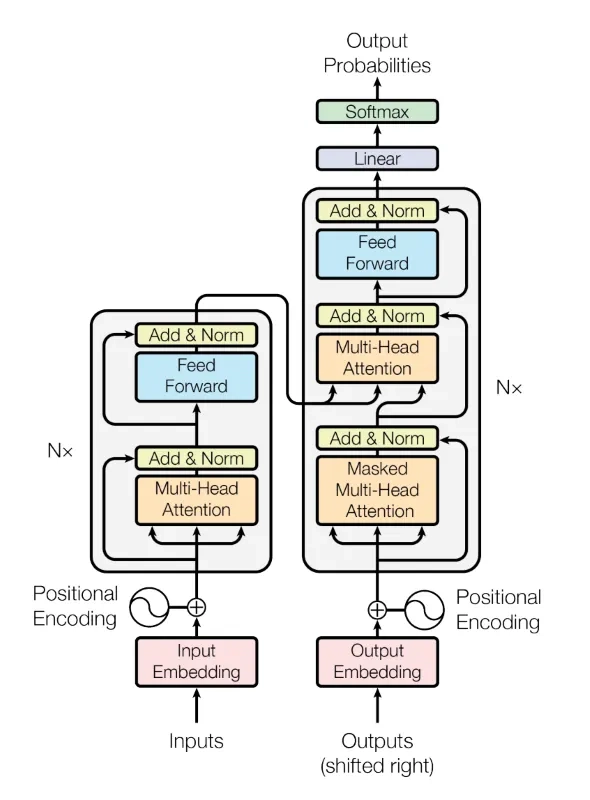
## 트랜스포머의 전처리 단계
> 1. 토큰화 (Tokenization)

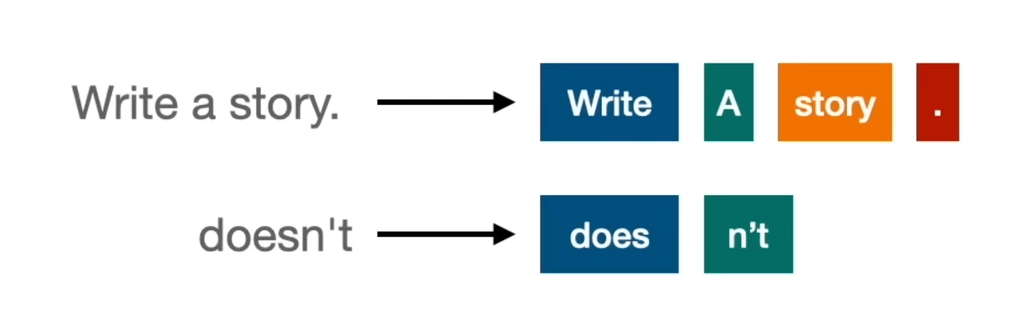
- **토큰화**는 입력 텍스트를 모델이 처리할 수 있는 단위(tokens)로 나누는 첫 번째 단계

- **토큰화 방법**
    1. 대부분의 경우 각 토큰은 하나의 **단어**에 해당. ex) `Write`, `A`, `Story` 
    2. 문장 부호 역시 별도의 토큰. ex) `.`, `!`
    3. 일부 단어는 하나 이상의 토큰으로 나뉠 수 있음. ex) `doesn’t` → `does`, `n’t`

> 2. 인베딩
- 임베딩의 구조
    - 임베딩은 많은 숫자로 이루어진 긴 벡터로 단어를 나타냄
    - 벡터의 길이 ⇒ 벡터의 차원

- 임베딩의 가장 중요한 원리는 단어의 의미를 공간적으로 표현하는 것
    - **유사한 단어 ⇒ 유사한 숫자**
    - 의미적으로 유사한 단어들은 임베딩 공간에서 유사한 숫자(좌표)로 변환되어야 함

    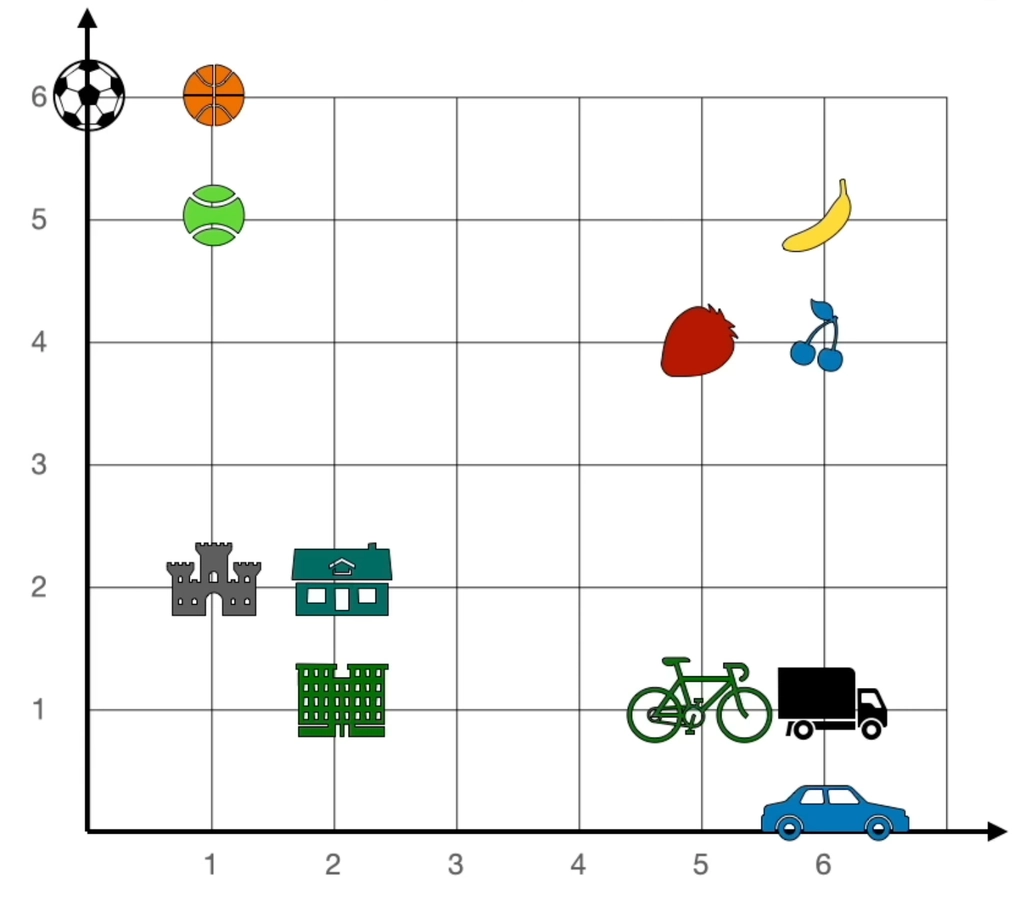

> 3. Positional Encoding
- Positional Encoding은 단어들의 순서 정보 를 임베딩 벡터에 추가하는 단계
- Transformer는 모든 단어를 병렬로 한 번에 처리해서, 단어의 순서를 알지 못함
- 같은 단어의 집합이라면 실제로는 의미가 다른데도 똑같은 것으로 인식
    - ex) "개는 고양이를 쫓는다"와 "고양이는 개를 쫓는다”을 다르다고 구분하지 못함

- **단어들은 문법적 측면이나, 문맥을 파악하기 위해서나 등장한 순서가 매우 중요하기 때문에, 이 순서 정보, 즉 위치 정보 를 제공하기 위해 positional encoding을 사용**

>> 사용 방법
- 각 단어의 임베딩 좌표에 일관된 순서(consistent sequence)를 따르는 다른 숫자를 추가하여 순서 정보를 기록
- 이 과정을 통해, 같은 단어라도 문장에서 차지하는 위치가 다르면 최종적으로 다른 좌표(수정된 임베딩)를 가지게 되며, 이는 모델이 순서를 학습할 수 있도록 함

## 트랜스포머의 Encoder와 Decoder
### Encoder

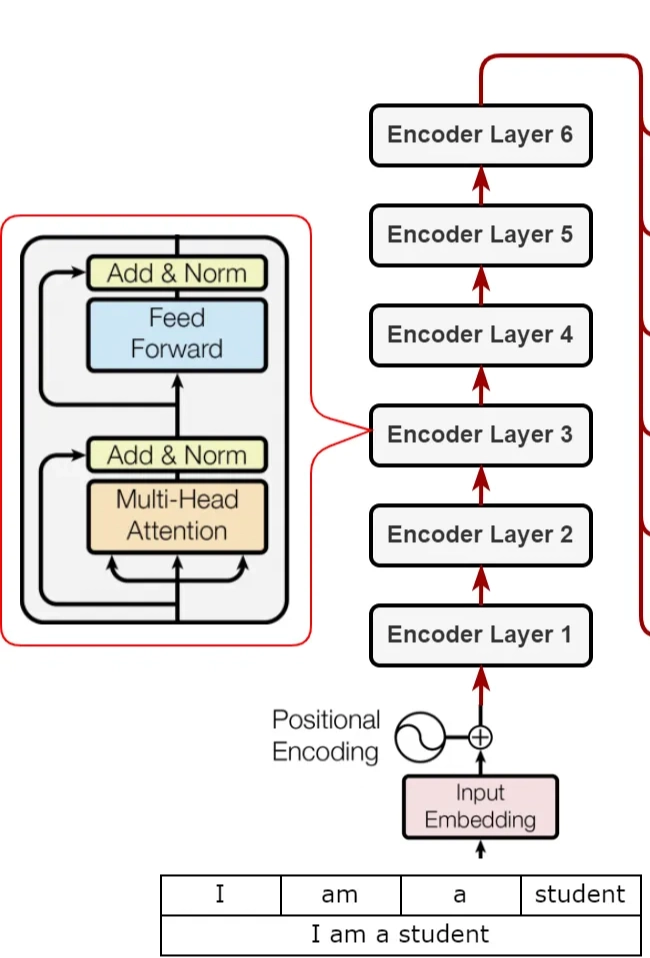
- 트랜스포머의 Encoder는 입력 문장을 이해하고 요약된 의미 벡터로 변환하는 역할
- 전처리 과정(토큰화, 임베딩, Positional Encoding) 및 인코더 레이어(Multi-Head Attention, Feed Forward Layer)로 구성

> 인코더 레이어의 구성

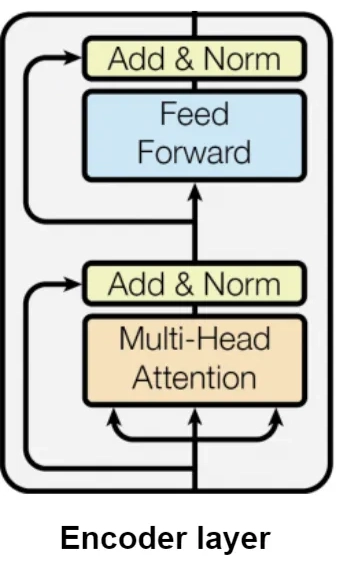
1. Multi-Head Attention
2. **Feed-Forward**
    - 입력 벡터의 차원을 확장하고 비선형 변환(ex: ReLU)을 적용하여 새로운 표현을 생성하는 신경망 구조
    - 입력된 문장을 번역한다고 할 때, 각 단어에 대해, 단어 하나하나를 전문 분석가에게 넘겨서 더 깊이 있는 설명으로 다듬는 것
    - Attention에서 어떤 단어를 더 집중해서 볼지를 정했다면, Feed-Forward에서는 그 단어에 대해 심층 분석을 하는 것

> Residual connections (잔차 연결)

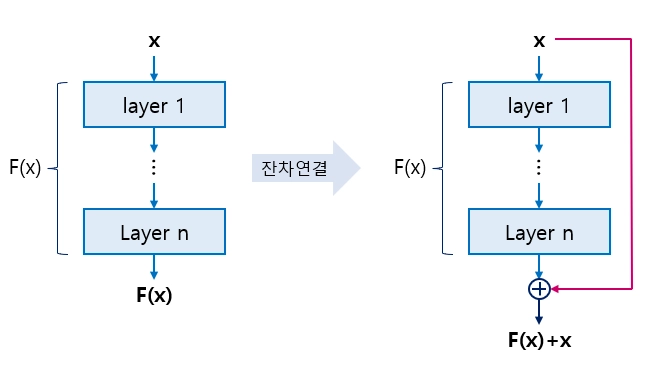
- 입력 값을 그대로 출력에 더해 주는 것
- RNN과 LSTM 모델에서 기울기 소실 문제가 있는데, 왼쪽 그림처럼 층이 쌓이게 되면 기울기 소실 및 폭주 현상이 발생할 수 있음
- 이를 해결하기 위해 오른쪽 그림처럼 지름길을 만들어서 출력에 입력값을 바로 전달

> Layer Normalization (층 정규화)
- 입력 벡터의 평균과 분산을 사용해서 정규화하는 것
- → 학습을 안정화하고 모델이 빠르게 수렴하게 만들어 줌

### Decoder

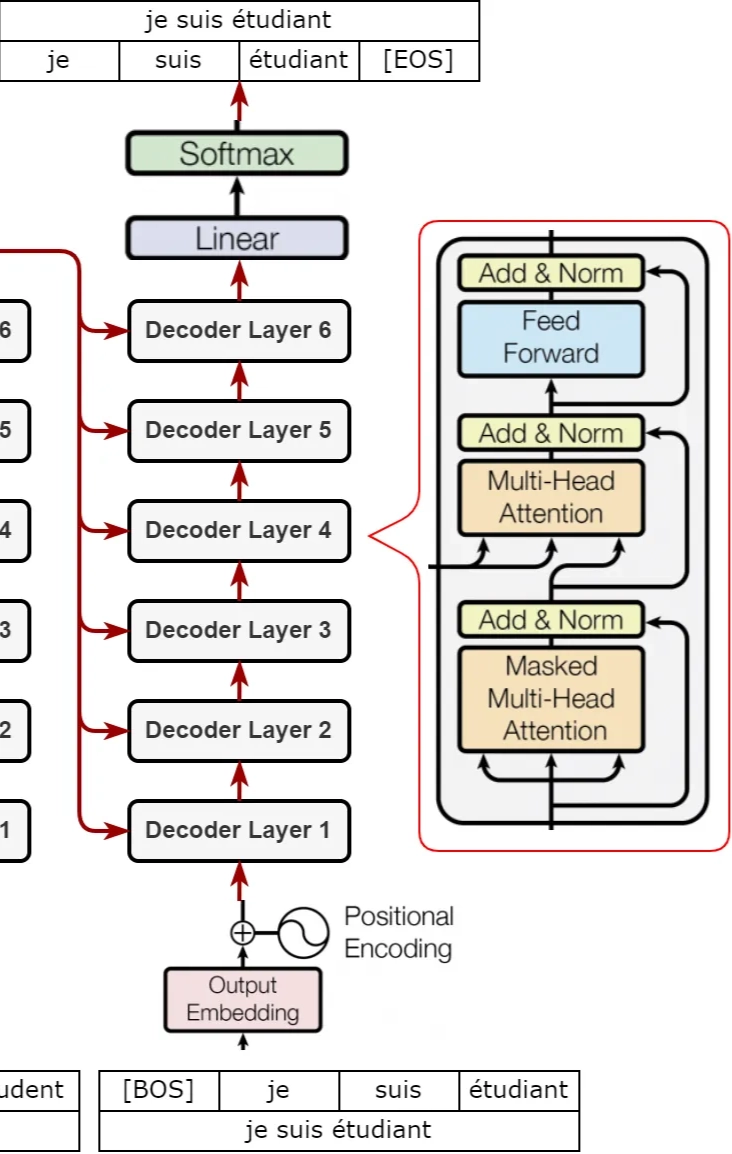
- 트랜스포머의 Decoder는 Encoder가 분석한 입력 문장의 의미 벡터를 받아서 출력 문장을 순차적으로 생성하는 역할
- 전처리 과정, 디코더 레이어, 선형 레이어와 소프트맥스 레이어로 구성

> 디코더 레이어의 구성

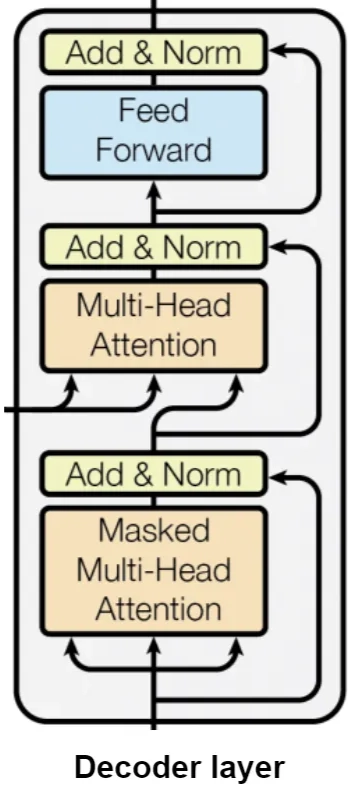
1. **Masked Multi-Head Attention**
    - 미래 시점의 단어 정보를 참고하지 못하도록 마스크(mask)를 적용하는 어텐션 메커니즘
    - 트랜스포머의 디코더는 시퀀스를 왼쪽에서 오른쪽으로(autogressive) 생성하며, 모델이 이미 생성된 단어들(과거 정보)만을 기반으로 다음 단어를 예측하도록 강제
    - 이를 위해 Look-Ahead Mask(Causal Mask)를 사용하여 현재 단어보다 오른쪽(미래)에 있는 토큰의 어텐션 값을 0으로 만들어 무시
2. **Encoder-Decoder** Multi-Head **Attention (Cross-Attention)**
    - 디코더가 인코더의 출력(Context)을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정
    - 입력 문장 중 어떤 부분에 주목해야 하는지를 학습
3. Feed-Forward Layer